location=marshfield | grid_source=asset_registry | assets=26344 | flood=single_use_case/run_stage/evt_0003


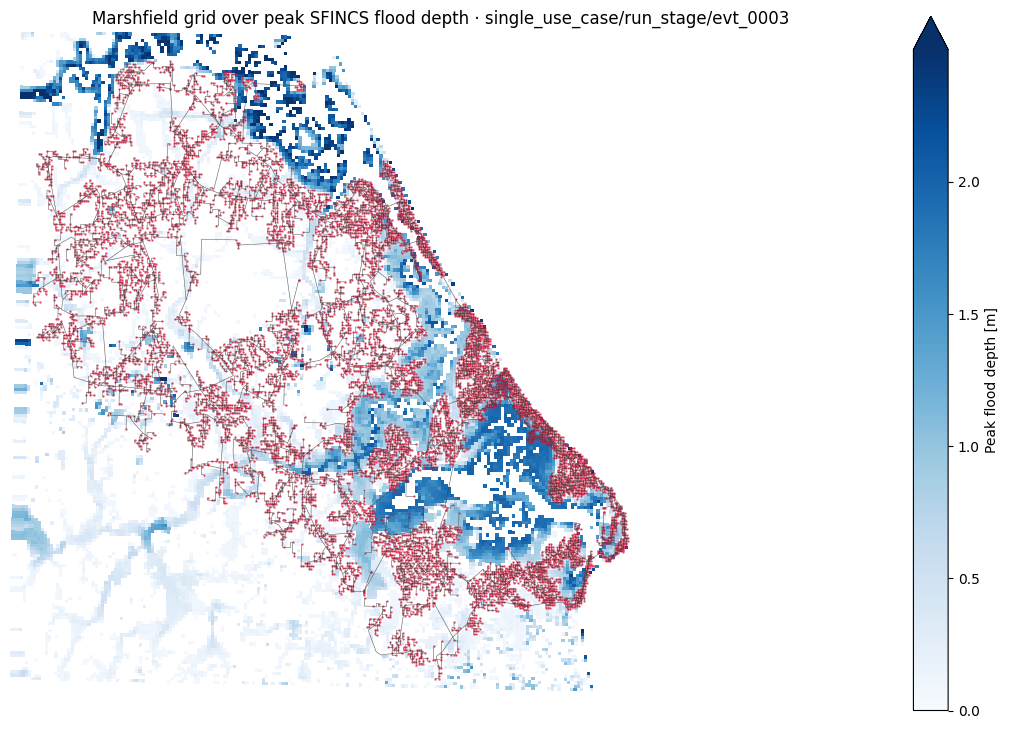

In [1]:
# Power grid x SFINCS flood overlay -- portable across Flood-RM locations.
# Resolves CRS from the SFINCS map, auto-detects the grid source (SMART-DS geojson or
# asset-registry CSVs), and finds the flood layer wherever the location stages it.
from pathlib import Path
import geopandas as gpd
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import LineString

location_root = Path("..").resolve()
location_name = location_root.name

# --- locate the flood layer (inland scenarios/<event>/<domain>/ or coastal run_outputs/<event>/) ---
flood_maps = sorted((location_root / "data" / "sfincs").glob("**/sfincs_map.nc"))
flood_map = flood_maps[-1] if flood_maps else None

# --- load the power grid from whichever source this location provides ---
def load_grid():
    geojsons = sorted((location_root / "data" / "smart_ds").glob("*/*/scenarios/base_timeseries/geojson/*.json"))
    if geojsons:  # SMART-DS feeders (greensboro, austin, sfo)
        g = pd.concat([gpd.read_file(p) for p in geojsons], ignore_index=True)
        if "type" not in g:
            g["type"] = "Node"
        return g[["type", "geometry"]].to_crs("EPSG:4326"), "smart_ds"
    reg = location_root / "data" / "power_grid" / "asset_registry"
    if reg.exists():  # OpenDSS asset registry (marshfield)
        def pts(csv, lon, lat, type_):
            df = pd.read_csv(reg / csv).dropna(subset=[lon, lat])
            gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy(df[lon], df[lat]), crs="EPSG:4326")
            gdf["type"] = type_
            return gdf
        frames = [
            pts("transformers.csv", "location_lon", "location_lat", "Transformer"),
            pts("loads.csv", "lon", "lat", "Load"),
            pts("sources.csv", "lon", "lat", "Source"),
        ]
        ln = pd.read_csv(reg / "lines.csv").dropna(subset=["from_lon", "from_lat", "to_lon", "to_lat"])
        geom = [LineString([(a, b), (c, d)]) for a, b, c, d in zip(ln.from_lon, ln.from_lat, ln.to_lon, ln.to_lat)]
        lines = gpd.GeoDataFrame(geometry=geom, crs="EPSG:4326")
        lines["type"] = "Line"
        frames.append(lines)
        return pd.concat(frames, ignore_index=True), "asset_registry"
    return None, "none"  # nothing staged yet; the overlay is ready once grid data lands

grid, grid_source = load_grid()

# --- plot in the SFINCS map's own CRS when a flood layer exists, else a geographic grid view ---
ds = depth = vmax = run_label = None
if grid is None:
    print(f"{location_name}: no power grid staged yet (no SMART-DS geojson or power_grid/asset_registry). "
          f"Overlay is ready to run once this location's grid data lands.")
else:
    if flood_map is not None:
        ds = xr.open_dataset(flood_map)
        plot_crs = ds["crs"].attrs.get("epsg_code") or "EPSG:4326"
        run_label = str(flood_map.parent.relative_to(location_root / "data" / "sfincs"))
        grid = grid.to_crs(plot_crs)

    fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
    if flood_map is not None:
        depth = (ds["zsmax"].max("timemax") - ds["zb"]).clip(min=0)
        # Drop sub-datum permanent water (coastal ocean) so land flooding stays visible; no-op inland.
        disp = depth.where((depth > 0.05) & (ds["zb"] >= 0.0))
        vmax = float(disp.quantile(0.99))
        mesh = ax.pcolormesh(ds["x"], ds["y"], disp, cmap="Blues", shading="nearest", vmin=0, vmax=vmax)
        fig.colorbar(mesh, ax=ax, shrink=0.7, extend="max", label="Peak flood depth [m]")
        minx, maxx = float(ds["x"].min()), float(ds["x"].max())
        miny, maxy = float(ds["y"].min()), float(ds["y"].max())
        grid = grid.cx[minx:maxx, miny:maxy]
        ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
        title = f"{location_name.title()} grid over peak SFINCS flood depth · {run_label}"
    else:
        title = f"{location_name.title()} power grid — no SFINCS flood staged yet"

    grid[grid["type"].eq("Line")].plot(ax=ax, linewidth=0.4, color="0.25", alpha=0.85)
    grid[~grid["type"].eq("Line")].plot(ax=ax, markersize=0.6, color="crimson", alpha=0.6)
    ax.set_aspect("equal"); ax.set_axis_off(); ax.set_title(title)
    print(f"location={location_name} | grid_source={grid_source} | assets={len(grid)} | flood={run_label or 'none'}")
    plt.show()


In [ ]:
# Plot peak flooding impacts over the exported ONM subregion.
# Uses the same asset-registry geometry source as the full overlay, but filters to
# marshfield_shift_synthetic_region_023 so the map matches onm_export_subregion.
import numpy as np
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree

SUBREGION_FEEDERS = ["marshfield_shift_synthetic_region_023"]
SUBREGION_IMPACT_FIGURE = location_root / "figures" / "subregion_flood_impacts.png"


def load_marshfield_subregion_assets():
    reg = location_root / "data" / "power_grid" / "asset_registry"
    smart = location_root / "data" / "static" / "power_grid" / "smart_ds_compat"

    lines = pd.read_csv(reg / "lines.csv")
    lines = lines[lines["feeder_id"].astype(str).isin(SUBREGION_FEEDERS)].dropna(
        subset=["from_lon", "from_lat", "to_lon", "to_lat"]
    )
    line_geom = [
        LineString([(row.from_lon, row.from_lat), (row.to_lon, row.to_lat)])
        for row in lines.itertuples(index=False)
    ]
    line_gdf = gpd.GeoDataFrame(lines, geometry=line_geom, crs="EPSG:4326")

    buses = pd.read_csv(reg / "buses.csv")
    buses = buses[buses["feeder_id"].astype(str).isin(SUBREGION_FEEDERS)].dropna(subset=["lon", "lat"])
    bus_gdf = gpd.GeoDataFrame(buses, geometry=gpd.points_from_xy(buses["lon"], buses["lat"]), crs="EPSG:4326")
    bus_gdf["asset_type"] = "Bus"

    transformers = pd.read_csv(reg / "transformers.csv")
    transformers = transformers[transformers["feeder_id"].astype(str).isin(SUBREGION_FEEDERS)].dropna(
        subset=["location_lon", "location_lat"]
    )
    transformer_gdf = gpd.GeoDataFrame(
        transformers,
        geometry=gpd.points_from_xy(transformers["location_lon"], transformers["location_lat"]),
        crs="EPSG:4326",
    )
    transformer_gdf["asset_type"] = "Transformer"

    sources = pd.read_csv(reg / "sources.csv")
    sources = sources[sources["feeder_id"].astype(str).isin(SUBREGION_FEEDERS)].dropna(subset=["lon", "lat"])
    source_gdf = gpd.GeoDataFrame(sources, geometry=gpd.points_from_xy(sources["lon"], sources["lat"]), crs="EPSG:4326")
    source_gdf["asset_type"] = "Voltage source"

    der_gdf = gpd.GeoDataFrame(columns=["der_id", "bus", "genset_kw", "asset_type", "geometry"], geometry="geometry", crs="EPSG:4326")
    der_path = smart / "der_inventory.parquet"
    if der_path.exists():
        ders = pd.read_parquet(der_path)
        live_ders = ders[
            ders["bus"].astype(str).str.split("__", n=1).str[0].isin(SUBREGION_FEEDERS)
            & ders["genset_kw"].fillna(0).gt(0)
        ].copy()
        if not live_ders.empty:
            der_gdf = live_ders.merge(bus_gdf[["bus", "geometry"]], on="bus", how="left")
            der_gdf["asset_type"] = "Live DER / backup generator"
            der_gdf = gpd.GeoDataFrame(der_gdf, geometry="geometry", crs="EPSG:4326").dropna(subset=["geometry"])

    return line_gdf, bus_gdf, transformer_gdf, source_gdf, der_gdf


def sample_depth(points, depth_raster):
    if points.empty:
        points = points.copy()
        points["depth_m"] = []
        points["impact"] = []
        return points
    cells = cKDTree(np.c_[ds["x"].values.ravel(), ds["y"].values.ravel()])
    _, idx = cells.query(np.c_[points.geometry.x, points.geometry.y])
    sampled = points.copy()
    sampled["depth_m"] = depth_raster.values.ravel()[idx]
    sampled["impact"] = pd.cut(
        sampled["depth_m"].fillna(0),
        bins=[-0.01, 0.05, 0.30, 0.90, float("inf")],
        labels=["dry", "minor", "moderate", "severe"],
    ).astype(str)
    return sampled


if flood_map is None:
    print("No staged SFINCS flood map found. Run the flood scenario first, then rerun this cell.")
elif ds is None:
    print("Run the first overlay cell before this one so the SFINCS dataset is loaded.")
else:
    line_gdf, bus_gdf, transformer_gdf, source_gdf, der_gdf = load_marshfield_subregion_assets()
    plot_crs = ds["crs"].attrs.get("epsg_code") or "EPSG:4326"
    line_plot = line_gdf.to_crs(plot_crs)
    bus_plot = bus_gdf.to_crs(plot_crs)
    transformer_plot = transformer_gdf.to_crs(plot_crs)
    source_plot = source_gdf.to_crs(plot_crs)
    der_plot = der_gdf.to_crs(plot_crs) if not der_gdf.empty else der_gdf

    depth_full = (ds["zsmax"].max("timemax") - ds["zb"]).clip(min=0)
    visible_depth = depth_full.where((depth_full > 0.05) & (ds["zb"] >= 0.0))
    local_vmax = vmax if vmax is not None else float(visible_depth.quantile(0.99))

    scored_frames = [
        sample_depth(bus_plot, depth_full),
        sample_depth(transformer_plot, depth_full),
        sample_depth(source_plot, depth_full),
        sample_depth(der_plot, depth_full) if not der_plot.empty else der_plot,
    ]
    scored_points = pd.concat([frame for frame in scored_frames if frame is not None and not frame.empty], ignore_index=True)
    impacted_points = scored_points[scored_points["depth_m"].fillna(0).gt(0.05)].copy()

    minx, miny, maxx, maxy = line_plot.total_bounds
    pad_x = max((maxx - minx) * 0.10, 300.0)
    pad_y = max((maxy - miny) * 0.10, 300.0)
    bounds = (minx - pad_x, maxx + pad_x, miny - pad_y, maxy + pad_y)

    fig, ax = plt.subplots(figsize=(9, 9), dpi=180)
    mesh = ax.pcolormesh(ds["x"], ds["y"], visible_depth, cmap="Blues", shading="nearest", vmin=0, vmax=local_vmax, zorder=0)
    cbar = fig.colorbar(mesh, ax=ax, shrink=0.62, pad=0.01, extend="max")
    cbar.set_label("Peak flood depth [m]")

    line_plot.plot(ax=ax, linewidth=0.50, color="#496b7d", alpha=0.76, zorder=2)
    bus_plot.plot(ax=ax, markersize=1.0, color="#64748b", alpha=0.32, zorder=3)
    transformer_plot.plot(ax=ax, markersize=11, color="#b99014", alpha=0.86, edgecolor="white", linewidth=0.25, zorder=4)
    source_plot.plot(ax=ax, markersize=38, color="#e11d48", alpha=0.94, edgecolor="white", linewidth=0.5, zorder=5)
    if not der_plot.empty:
        der_plot.plot(ax=ax, markersize=78, color="#7c3aed", marker="*", alpha=0.96, edgecolor="white", linewidth=0.45, zorder=7)

    if not impacted_points.empty:
        impacted_points.plot(
            ax=ax,
            column="depth_m",
            cmap="YlOrRd",
            markersize=36,
            alpha=0.88,
            edgecolor="#111827",
            linewidth=0.25,
            zorder=6,
        )

    legend_handles = [
        Line2D([0], [0], color="#496b7d", lw=1.7, label="Subregion distribution line"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#64748b", markeredgecolor="none", markersize=4, label="Bus"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#b99014", markeredgecolor="white", markersize=7, label="Transformer"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#e11d48", markeredgecolor="white", markersize=8, label="Voltage source"),
        Line2D([0], [0], marker="*", color="none", markerfacecolor="#7c3aed", markeredgecolor="white", markersize=11, label="Live DER / backup generator"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#f97316", markeredgecolor="#111827", markersize=7, label="Flood-impacted point asset"),
    ]
    ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True, framealpha=0.96, facecolor="white", edgecolor="#cbd5e1", fontsize=8)
    ax.set_xlim(bounds[0], bounds[1])
    ax.set_ylim(bounds[2], bounds[3])
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(
        "Marshfield peak flood impacts on exported ONM subregion\n"
        f"{', '.join(SUBREGION_FEEDERS)} · {run_label}"
    )
    SUBREGION_IMPACT_FIGURE.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(SUBREGION_IMPACT_FIGURE, bbox_inches="tight", pad_inches=0.18, facecolor="white")
    plt.close(fig)
    print(
        f"saved={SUBREGION_IMPACT_FIGURE} | point_assets={len(scored_points)} | "
        f"impacted={len(impacted_points)} | max_depth_m={scored_points['depth_m'].max():.2f}"
    )
    display(Image(filename=SUBREGION_IMPACT_FIGURE))
